# 01 - Exploratory Data Analysis (EDA)
## Explainable Loan Eligibility Prediction Using EBM

This notebook explores the synthetic loan-applicant dataset before we train
the Explainable Boosting Machine (EBM) model. We look at:
1. Basic structure and missing values
2. Distribution of the target (`loan_status`)
3. How key features (credit score, income, existing loans) relate to approval

Run `python data/generate_dataset.py` first if `data/loan_data.csv` doesn't exist yet.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/loan_data.csv")
df.head()

,age,gender,married,dependents,education,self_employed,employment_type,applicant_income,coapplicant_income,credit_score,loan_amount,loan_term_months,existing_loans_count,property_area,loan_status
0,24,Male,Yes,0,Graduate,No,Self-Employed,48634,11620,767,130,240,2,Rural,Approved
1,51,Female,Yes,1,Graduate,No,Salaried,24999,14734,693,212,240,1,Urban,Approved
2,46,Male,Yes,0,Graduate,No,Salaried,56800,0,723,171,240,1,Semiurban,Approved
3,38,Male,Yes,0,Graduate,No,Self-Employed,16073,8946,570,94,240,0,Rural,Rejected
4,37,Female,Yes,0,Graduate,Yes,Salaried,34572,0,745,151,120,1,Rural,Approved


## 1. Basic structure

In [2]:
print("Shape:", df.shape)
print()
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isna().sum())

Shape: (3000, 15)

age                     int64
gender                    str
married                   str
dependents              int64
education                 str
self_employed             str
employment_type           str
applicant_income        int64
coapplicant_income      int64
credit_score            int64
loan_amount             int64
loan_term_months        int64
existing_loans_count    int64
property_area             str
loan_status               str
dtype: object

Missing values per column:
age                     0
gender                  0
married                 0
dependents              0
education               0
self_employed           0
employment_type         0
applicant_income        0
coapplicant_income      0
credit_score            0
loan_amount             0
loan_term_months        0
existing_loans_count    0
property_area           0
loan_status             0
dtype: int64


## 2. Target distribution (Approved vs Rejected)

loan_status
Approved    1824
Rejected    1176
Name: count, dtype: int64

loan_status
Approved    60.8%
Rejected    39.2%
Name: count, dtype: str


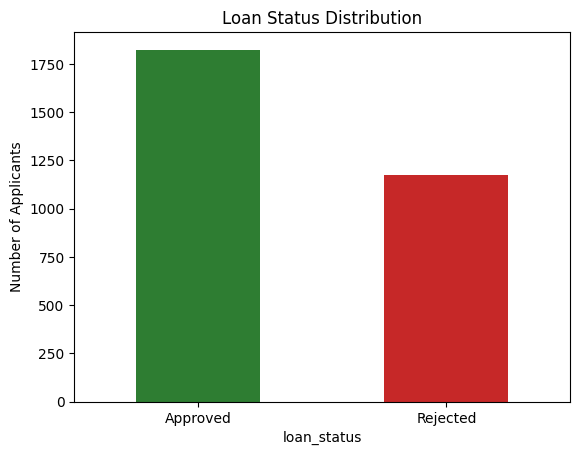

In [3]:
counts = df["loan_status"].value_counts()
print(counts)
print()
print((counts / len(df) * 100).round(1).astype(str) + "%")

counts.plot(kind="bar", color=["#2e7d32", "#c62828"])
plt.title("Loan Status Distribution")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.show()

## 3. Credit score vs approval\nCredit score is expected to be the strongest signal (like a CIBIL score in India).

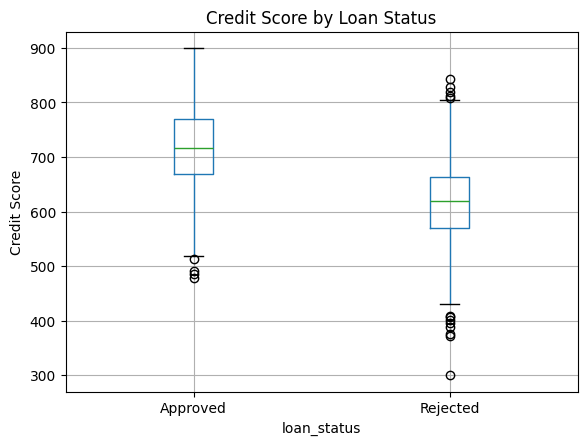

              count        mean        std    min    25%    50%    75%    max
loan_status                                                                  
Approved     1824.0  719.141996  75.214377  479.0  668.0  717.0  770.0  900.0
Rejected     1176.0  616.476190  71.286031  300.0  570.0  618.5  664.0  843.0


In [4]:
df.boxplot(column="credit_score", by="loan_status")
plt.title("Credit Score by Loan Status")
plt.suptitle("")
plt.ylabel("Credit Score")
plt.show()

print(df.groupby("loan_status")["credit_score"].describe())

## 4. Income vs approval

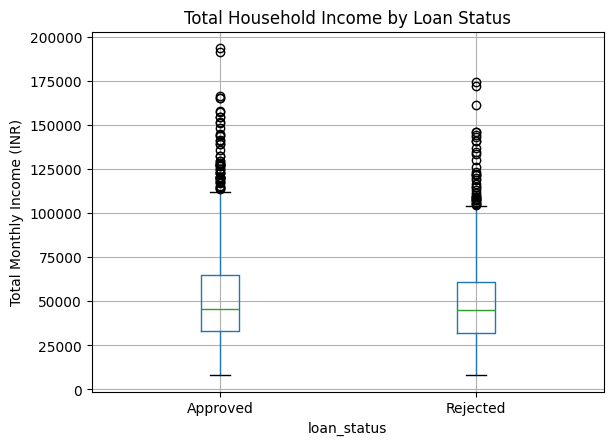

In [5]:
df["total_income"] = df["applicant_income"] + df["coapplicant_income"]
df.boxplot(column="total_income", by="loan_status")
plt.title("Total Household Income by Loan Status")
plt.suptitle("")
plt.ylabel("Total Monthly Income (INR)")
plt.show()

## 5. Existing loans vs approval rate

existing_loans_count
0    0.641700
1    0.606466
2    0.555085
3    0.449664
Name: loan_status, dtype: float64


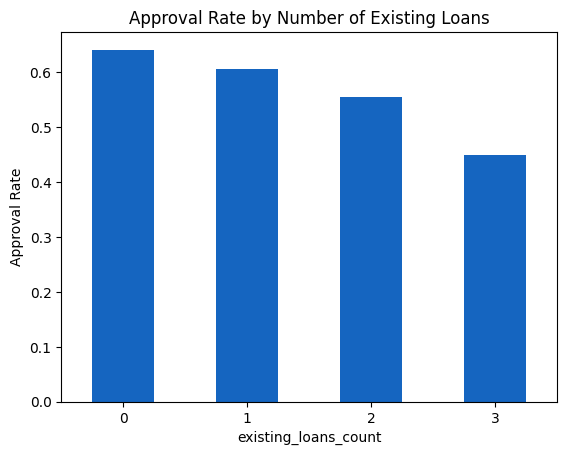

In [6]:
approval_by_existing = (
    df.groupby("existing_loans_count")["loan_status"]
    .apply(lambda s: (s == "Approved").mean())
)
print(approval_by_existing)

approval_by_existing.plot(kind="bar", color="#1565c0")
plt.title("Approval Rate by Number of Existing Loans")
plt.ylabel("Approval Rate")
plt.xticks(rotation=0)
plt.show()

## 6. Employment type & education vs approval rate

In [7]:
for col in ["employment_type", "education", "property_area"]:
    print(f"\nApproval rate by {col}:")
    print(df.groupby(col)["loan_status"].apply(lambda s: (s == "Approved").mean()).round(3))


Approval rate by employment_type:
employment_type
Business         0.576
Salaried         0.616
Self-Employed    0.609
Name: loan_status, dtype: float64

Approval rate by education:
education
Graduate        0.621
Not Graduate    0.559
Name: loan_status, dtype: float64

Approval rate by property_area:
property_area
Rural        0.615
Semiurban    0.625
Urban        0.587
Name: loan_status, dtype: float64


## Takeaways

- Credit score has a clear, strong relationship with approval - higher scores approve more often.
- Total household income also matters, but less sharply than credit score.
- Having more existing loans clearly lowers approval rate (more existing debt = riskier).
- Employment type, education, and property area show smaller but visible effects.

These match what we'd expect from a real bank's underwriting logic, and they are exactly
the kind of factors the EBM model in `src/train_model.py` will learn and later explain
in plain English inside the Streamlit app (`app.py`).